# Executive Summary

Platform Direkrut AI
Platform recruitment berbasis AI yang mengotomasi screening CV dan interview kandidat menggunakan:
- AI Engine: OpenAI GPT-4o-mini
- Backend: Python (FastAPI)
- Frontend: Next.js
- Database: PostgreSQL + pgvector
- Infrastructure: Microsoft Azure

Analisis menghitung Total Cost of Ownership (TCO)
1. Startup (1,000 candidates/month)
2. Growth (5,000 candidates/month)
3. Scale (10,000 candidates/month)
4. Enterprise (25,000 candidates/month)


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings


# Asumsi & Parameter

In [24]:
business_assumptions = {
    'kandidat_per_bulan': {
        'low': 1000, 
        'medium': 5000,
        'high': 10000,
        'enterprise' : 25000
    },
    'avg_cv_pages': 2,
    'avg_cv_size_mb': 0.5,
    'avg_interview_duration_min': 15,
    'companies_active': {
        'low': 10, 
        'medium': 50,
        'high': 150,
        'enterprise': 500
    },
    'avg_job_postings_per_company': 5
}

df_assumptions = pd.DataFrame([
    {'Scenario': 'Startup Phase', 'Kandidat/Bulan': '1,000', 'Perusahaan': 10, 'Job Postings': 50},
    {'Scenario': 'Growth Phase', 'Kandidat/Bulan': '5,000', 'Perusahaan': 50, 'Job Postings': 250},
    {'Scenario': 'Scale Phase', 'Kandidat/Bulan': '10,000', 'Perusahaan': 150, 'Job Postings': 750},
    {'Scenario': 'Enterprise Phase', 'Kandidat/Bulan': '25,000', 'Perusahaan': 500, 'Job Postings': 2500}
])

print(df_assumptions.to_string(index=False))

        Scenario Kandidat/Bulan  Perusahaan  Job Postings
   Startup Phase          1,000          10            50
    Growth Phase          5,000          50           250
     Scale Phase         10,000         150           750
Enterprise Phase         25,000         500          2500


In [25]:
openai_pricing = {
    'input_per_1m': 0.150,   
    'output_per_1m': 0.600,  
}

# Azure Infrastructure Pricing
azure_pricing = {
    'app_service_basic': {  
        'startup': 13.14,      
        'growth': 54.75,       
        'scale': 109.50,       
        'enterprise': 109.50,  
    },
    'database': {  
        'startup': 24.82,     
        'growth': 54.75,       
        'scale': 109.50,       
        'enterprise': 219.00,  
    },
    'blob_storage_per_gb': 0.0184, 
    'egress_per_gb': 0.087,         
}
token_usage = {
    'cv_parsing': {'input': 2000, 'output': 500},
    'cv_analysis': {'input': 3000, 'output': 1000},
    'interview_generation': {'input': 2500, 'output': 800},
    'interview_qa_per_round': {'input': 1500, 'output': 600},
    'final_assessment': {'input': 4000, 'output': 1500},
}
business_assumptions = {
    'avg_interview_rounds': 5,
    'avg_cv_size_mb': 0.5,
    'data_retention_months': 12,
}
print(f"OpenAI Input:  ${openai_pricing['input_per_1m']}/1M tokens")
print(f"OpenAI Output: ${openai_pricing['output_per_1m']}/1M tokens")
print(f"Azure App Service (Startup): ${azure_pricing['app_service_basic']['startup']}/month")
print(f"Azure Database (Startup): ${azure_pricing['database']['startup']}/month")

OpenAI Input:  $0.15/1M tokens
OpenAI Output: $0.6/1M tokens
Azure App Service (Startup): $13.14/month
Azure Database (Startup): $24.82/month


In [26]:
def calculate_ai_cost_per_candidate(token_usage, pricing, avg_qa_rounds=5):
    total_input = (
        token_usage['cv_parsing']['input'] +
        token_usage['cv_analysis']['input'] +
        token_usage['interview_generation']['input'] +
        (token_usage['interview_qa_per_round']['input'] * avg_qa_rounds) +
        token_usage['final_assessment']['input']
    )
    
    total_output = (
        token_usage['cv_parsing']['output'] +
        token_usage['cv_analysis']['output'] +
        token_usage['interview_generation']['output'] +
        (token_usage['interview_qa_per_round']['output'] * avg_qa_rounds) +
        token_usage['final_assessment']['output']
    )
    
    input_cost = (total_input / 1_000_000) * pricing['input_per_1m']
    output_cost = (total_output / 1_000_000) * pricing['output_per_1m']
    
    return {
        'total_input_tokens': total_input,
        'total_output_tokens': total_output,
        'input_cost': input_cost,
        'output_cost': output_cost,
        'total': input_cost + output_cost
    }
ai_cost_breakdown = calculate_ai_cost_per_candidate(
    token_usage, 
    openai_pricing, 
    business_assumptions['avg_interview_rounds']
)
print(f"Total Input Tokens {ai_cost_breakdown['total_input_tokens']:,}")
print(f"Total Output Tokens {ai_cost_breakdown['total_output_tokens']:,}")
print(f"Input Cost ${ai_cost_breakdown['input_cost']:.6f}")
print(f"Output Cost ${ai_cost_breakdown['output_cost']:.6f}")
print(f"Total per Candidate ${ai_cost_breakdown['total']:.6f}")

Total Input Tokens 19,000
Total Output Tokens 6,800
Input Cost $0.002850
Output Cost $0.004080
Total per Candidate $0.006930


In [27]:
def calculate_storage_cost(num_candidates, avg_cv_size_mb, months_retention=12):
    total_storage_gb = (num_candidates * avg_cv_size_mb * months_retention) / 1024
    storage_cost = total_storage_gb * azure_pricing['blob_storage_per_gb']
    db_storage_gb = (num_candidates * 2 * months_retention) / 1024
    return {
    'blob_storage_gb': total_storage_gb,
    'blob_cost': storage_cost,
    'database_storage_gb': db_storage_gb,
    'total_storage_gb': total_storage_gb + db_storage_gb
    }

storage_test = calculate_storage_cost(5000, 0.5, 12)
print("Storage Cost Estimation")
print(f"Blob Storage {storage_test['blob_storage_gb']:.2f} GB")
print(f"Database Storage {storage_test['database_storage_gb']:.2f} GB")
print(f"Total Storage {storage_test['total_storage_gb']:.2f} GB")
print(f"Monthly Blob Cost ${storage_test['blob_cost']:.2f}")

Storage Cost Estimation
Blob Storage 29.30 GB
Database Storage 117.19 GB
Total Storage 146.48 GB
Monthly Blob Cost $0.54


In [28]:
def calculate_total_opex(scenario='medium', candidates_per_month=5000):
    ai_per_candidate = ai_cost_breakdown['total']
    ai_total_monthly = ai_per_candidate * candidates_per_month

    app_service_cost = azure_pricing['app_service_basic'][scenario]
    database_cost = azure_pricing['database'][scenario]

    storage = calculate_storage_cost(candidates_per_month, 0.5, 12)
    storage_cost = storage['blob_cost']

    egress_db = storage['total_storage_gb'] * 0.1
    egress_cost = egress_db * azure_pricing['egress_per_gb']

    compute_total = app_service_cost + database_cost
    ai_total = ai_total_monthly
    storage_total = storage_cost + egress_cost

    grand_total = compute_total + ai_total + storage_total

    result = {
        'scenario': scenario.upper(),
        'candidates_per_month': candidates_per_month,

        'app_service': app_service_cost,
        'database': database_cost,
        'compute_total': compute_total,
        'storage_total': storage_total,
        'blob_storage': storage_cost,
        'data_transfer': egress_cost,
        'storage_percentage': (storage_total / grand_total) * 100,
        'grand_total': grand_total,
        'cost_per_candidate': grand_total / candidates_per_month,
        'ai_token_cost': ai_total,
        'ai_percentage': (ai_total / grand_total) * 100,
        'compute_percentage': (compute_total / grand_total) * 100
    }

    return result

scenarios = ['startup', 'growth', 'scale', 'enterprise']
candidates = [1000, 5000, 10000, 25000]

results = []
for scenario, num_candidates in zip(scenarios, candidates):
    result = calculate_total_opex(scenario, num_candidates)
    results.append(result)

df_opex = pd.DataFrame(results)

print("Complete Opex Breakdown")

for _, row in df_opex.iterrows():
    print(f" {row['scenario']} Phase ({row['candidates_per_month']:,} candidates/month)")
    print("(Azure)")
    print(f"App Service : ${row['app_service']}")
    print(f"Database    : (PostgreSQL) ${row['database']}")
    print(f"Subtotal    : ${row['compute_total']} ({row['ai_percentage']} %)")
    print("OpenAI GPT-4o-mini")
    print(f"Total       : ${row['ai_token_cost']} ({row['ai_percentage']}%)")
    print(f"Storage & Data Transfer")
    print(f"Blob Storage : ${row['blob_storage']}")
    print(f"Data Transfer: ${row['data_transfer']}")
    print(f"Sub total    : ${row['storage_total']} ({row['storage_percentage']}%)")
    print(f"Total Seluruhnya: ${row['grand_total']} /month")
    print(f"Cost per candidate: ${row['cost_per_candidate']}")



Complete Opex Breakdown
 STARTUP Phase (1,000 candidates/month)
(Azure)
App Service : $13.14
Database    : (PostgreSQL) $24.82
Subtotal    : $37.96 (15.314004949636113 %)
OpenAI GPT-4o-mini
Total       : $6.929999999999999 (15.314004949636113%)
Storage & Data Transfer
Blob Storage : $0.10781249999999999
Data Transfer: $0.2548828125
Sub total    : $0.3626953125 (0.8014888615923257%)
Total Seluruhnya: $45.2526953125 /month
Cost per candidate: $0.0452526953125
 GROWTH Phase (5,000 candidates/month)
(Azure)
App Service : $54.75
Database    : (PostgreSQL) $54.75
Subtotal    : $109.5 (23.738815226947022 %)
OpenAI GPT-4o-mini
Total       : $34.64999999999999 (23.738815226947022%)
Storage & Data Transfer
Blob Storage : $0.5390625
Data Transfer: $1.2744140625
Sub total    : $1.8134765625 (1.2424180385450665%)
Total Seluruhnya: $145.96347656249998 /month
Cost per candidate: $0.029192695312499996
 SCALE Phase (10,000 candidates/month)
(Azure)
App Service : $109.5
Database    : (PostgreSQL) $109.5

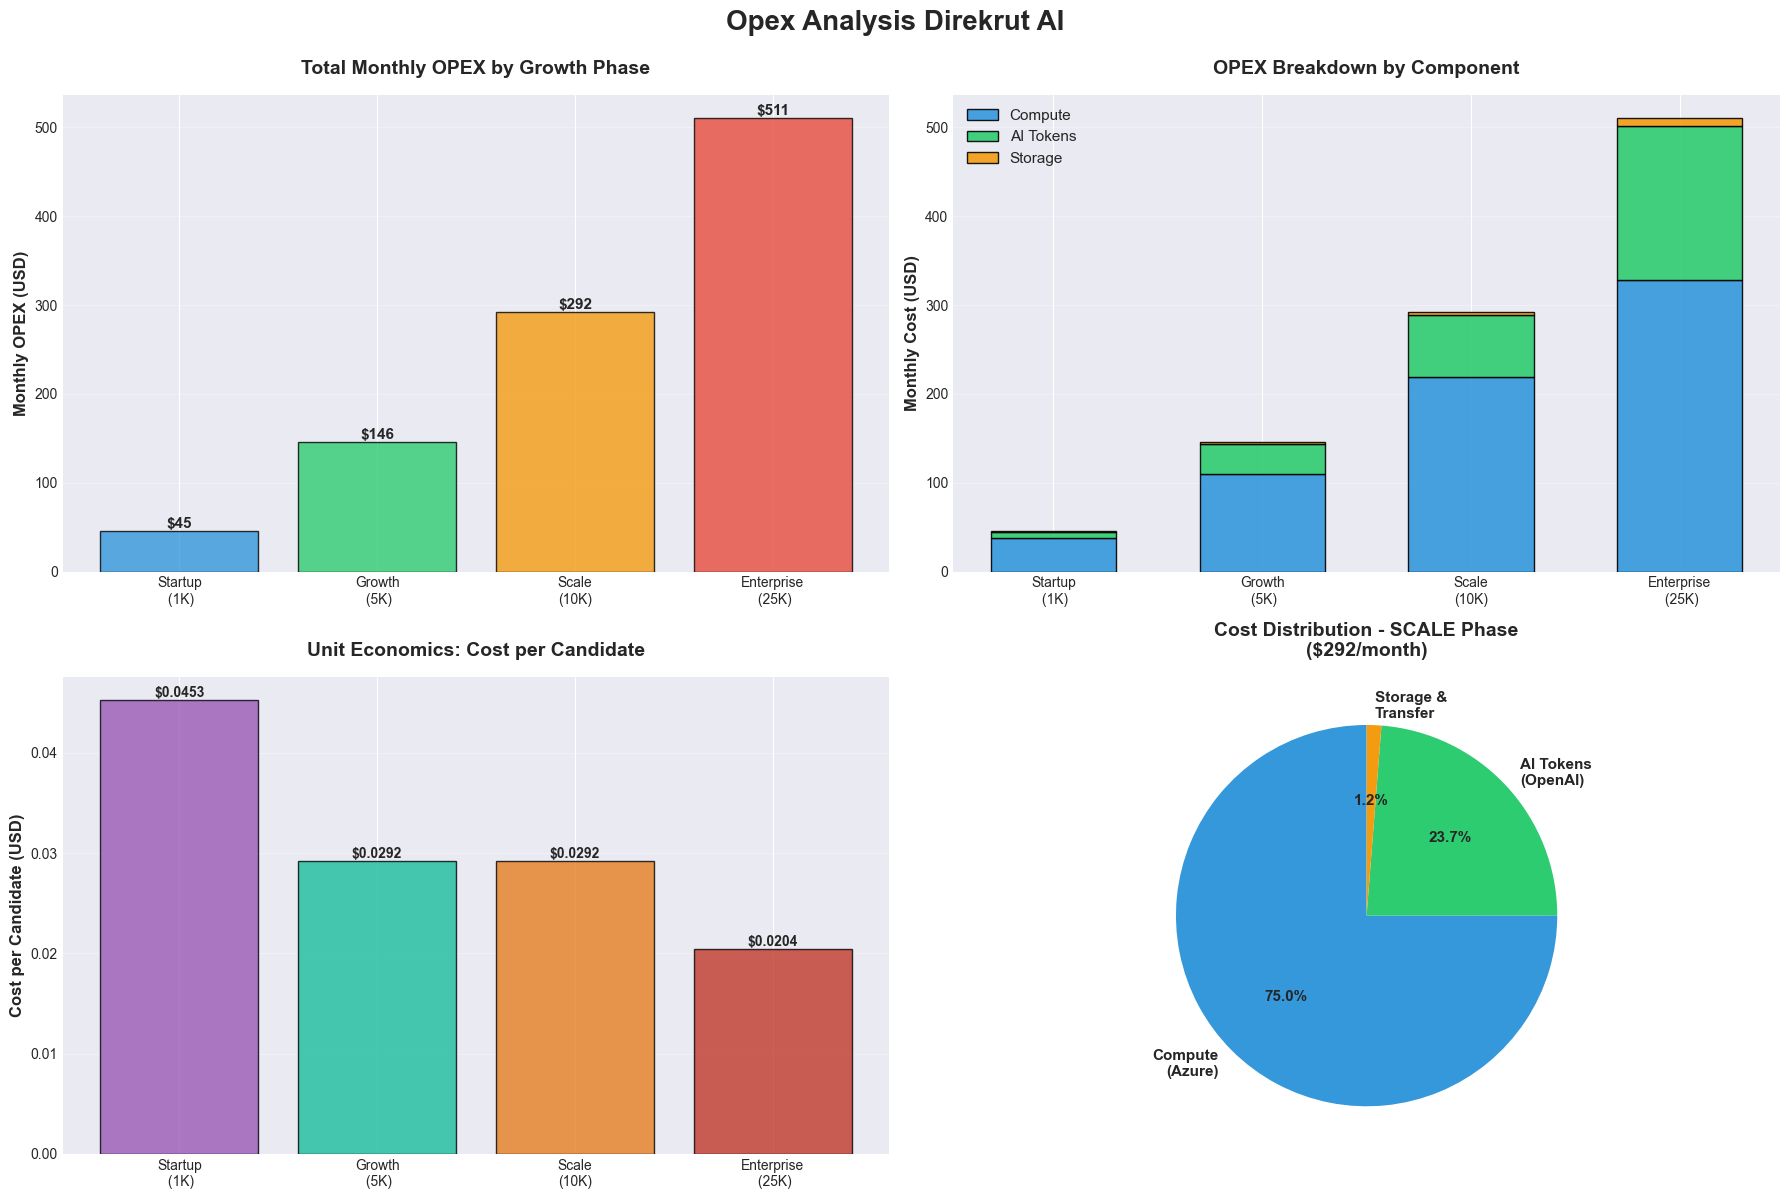

In [30]:
fig, axes = plt.subplots(2,2, figsize=(18,12))
fig.suptitle("Opex Analysis Direkrut AI", fontsize=20, fontweight='bold', y=0.995)
scenarios_labels = ['Startup\n (1K)', 'Growth\n (5K)', 'Scale\n(10K)', 'Enterprise\n (25K)']

ax1 = axes[0,0]
bars = ax1.bar(scenarios_labels, df_opex['grand_total'], color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'], alpha=0.8, edgecolor='black')
ax1.set_ylabel('Monthly OPEX (USD)', fontsize=12, fontweight='bold')
ax1.set_title('Total Monthly OPEX by Growth Phase', fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:,.0f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2 = axes[0, 1]
compute_costs = df_opex['compute_total']
ai_costs = df_opex['ai_token_cost']
storage_costs = df_opex['storage_total']

x_pos = np.arange(len(scenarios_labels))
width = 0.6

p1 = ax2.bar(x_pos, compute_costs, width, label='Compute', color='#3498db', alpha=0.9, edgecolor='black')
p2 = ax2.bar(x_pos, ai_costs, width, bottom=compute_costs, label='AI Tokens', color='#2ecc71', alpha=0.9, edgecolor='black')
p3 = ax2.bar(x_pos, storage_costs, width, bottom=compute_costs+ai_costs, label='Storage', color='#f39c12', alpha=0.9, edgecolor='black')

ax2.set_ylabel('Monthly Cost (USD)', fontsize=12, fontweight='bold')
ax2.set_title('OPEX Breakdown by Component', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(scenarios_labels)
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[1, 0]
bars = ax3.bar(scenarios_labels, df_opex['cost_per_candidate'], color=['#9b59b6', '#1abc9c', '#e67e22', '#c0392b'], alpha=0.8, edgecolor='black')
ax3.set_ylabel('Cost per Candidate (USD)', fontsize=12, fontweight='bold')
ax3.set_title('Unit Economics: Cost per Candidate', fontsize=14, fontweight='bold', pad=15)
ax3.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'${height:.4f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

ax4 = axes[1, 1]
scale_idx = 2
categories = ['Compute\n(Azure)', 'AI Tokens\n(OpenAI)', 'Storage &\nTransfer']
values = [
    df_opex.iloc[scale_idx]['compute_total'],
    df_opex.iloc[scale_idx]['ai_token_cost'],
    df_opex.iloc[scale_idx]['storage_total']
]
colors_pie = ['#3498db', '#2ecc71', '#f39c12']

wedges, texts, autotexts = ax4.pie(values, labels=categories, colors=colors_pie,
                                     autopct='%1.1f%%', startangle=90, 
                                     textprops={'fontsize': 11, 'fontweight': 'bold'})
ax4.set_title(f'Cost Distribution - SCALE Phase\n(${df_opex.iloc[scale_idx]["grand_total"]:,.0f}/month)', 
              fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()


In [31]:
pricing_tiers = {
    'starter': {
        'price_per_month': 31.85,
        'included_candidates': 100,
        'price_per_extra_candidate': 0.30,
        'target_customers': ['Startup', 'Small Business']
    },
    'professional': {
        'price_per_month': 127.39,
        'included_candidates': 500,
        'price_per_extra_candidate': 0.25,
        'target_customers': ['Growing Companies', 'SMEs']
    },
    'enterprise': {
        'price_per_month': 477.71,
        'included_candidates': 3000,
        'price_per_extra_candidate': 0.15,
        'target_customers': ['Large Corporations', 'Unicorns']
    }
}

customer_mix = {
    'startup': {
        'starter': 5, 
        'professional': 0,
        'enterprise': 0,
    },
    'growth': {
        'starter': 15,
        'professional': 3,
        'enterprise': 0,
    },
    'scale': {
        'starter': 30, 
        'professional': 10, 
        'enterprise': 1
    },
    'enterprise': {
        'starter': 50, 
        'professional': 25, 
        'enterprise': 3
    }
}

def calculate_mrr(customer_counts, pricing):
    mrr =0
    for tier, count in customer_counts.items():
        mrr += pricing[tier]['price_per_month'] * count
    return mrr

mrr_by_scenario = {}
for scenario, customers in customer_mix.items():
    mrr_by_scenario[scenario] = calculate_mrr(customers, pricing_tiers)

df_opex['mrr'] = [mrr_by_scenario[s] for s in scenarios]
df_opex['profit'] = df_opex['mrr'] - df_opex['grand_total']
df_opex['profit_margin'] = (df_opex['profit'] / df_opex['mrr'] * 100)

print("Revenue Model & Profitability")
for i, scenario in enumerate(scenarios):
    row = df_opex.iloc[i]
    customers = customer_mix[scenario]

    print(f"{scenario.upper} Phase")
    print(f"Customer Mix")
    print(f"Starter {customers['starter']:>3} customers x ${pricing_tiers['starter']['price_per_month']}")
    print(f"Professional {customers['professional']:>3} customers x {pricing_tiers['professional']['price_per_month']}")
    print(f"Enterprise {customers['enterprise']:>3} customers x ${pricing_tiers['enterprise']['price_per_month']}")
    print(f"Monthly Recurring Revenue (MRR) ${row['mrr']}")
    print(f"Total Opex: ${row['grand_total']}")
    print(f" {'Net Profit' if row['profit'] > 0 else 'Net Loss'}: ${row['profit']} ({row['profit_margin']} %)")
        

Revenue Model & Profitability
<built-in method upper of str object at 0x106f64d20> Phase
Customer Mix
Starter   5 customers x $31.85
Professional   0 customers x 127.39
Enterprise   0 customers x $477.71
Monthly Recurring Revenue (MRR) $159.25
Total Opex: $45.2526953125
 Net Profit: $113.99730468749999 (71.58386479591836 %)
<built-in method upper of str object at 0x110b6f1e0> Phase
Customer Mix
Starter  15 customers x $31.85
Professional   3 customers x 127.39
Enterprise   0 customers x $477.71
Monthly Recurring Revenue (MRR) $859.9200000000001
Total Opex: $145.96347656249998
 Net Profit: $713.9565234375001 (83.0259237414527 %)
<built-in method upper of str object at 0x106d39860> Phase
Customer Mix
Starter  30 customers x $31.85
Professional  10 customers x 127.39
Enterprise   1 customers x $477.71
Monthly Recurring Revenue (MRR) $2707.11
Total Opex: $291.92695312499995
 Net Profit: $2415.1830468750004 (89.21628773396722 %)
<built-in method upper of str object at 0x11164d3b0> Phase
Cus

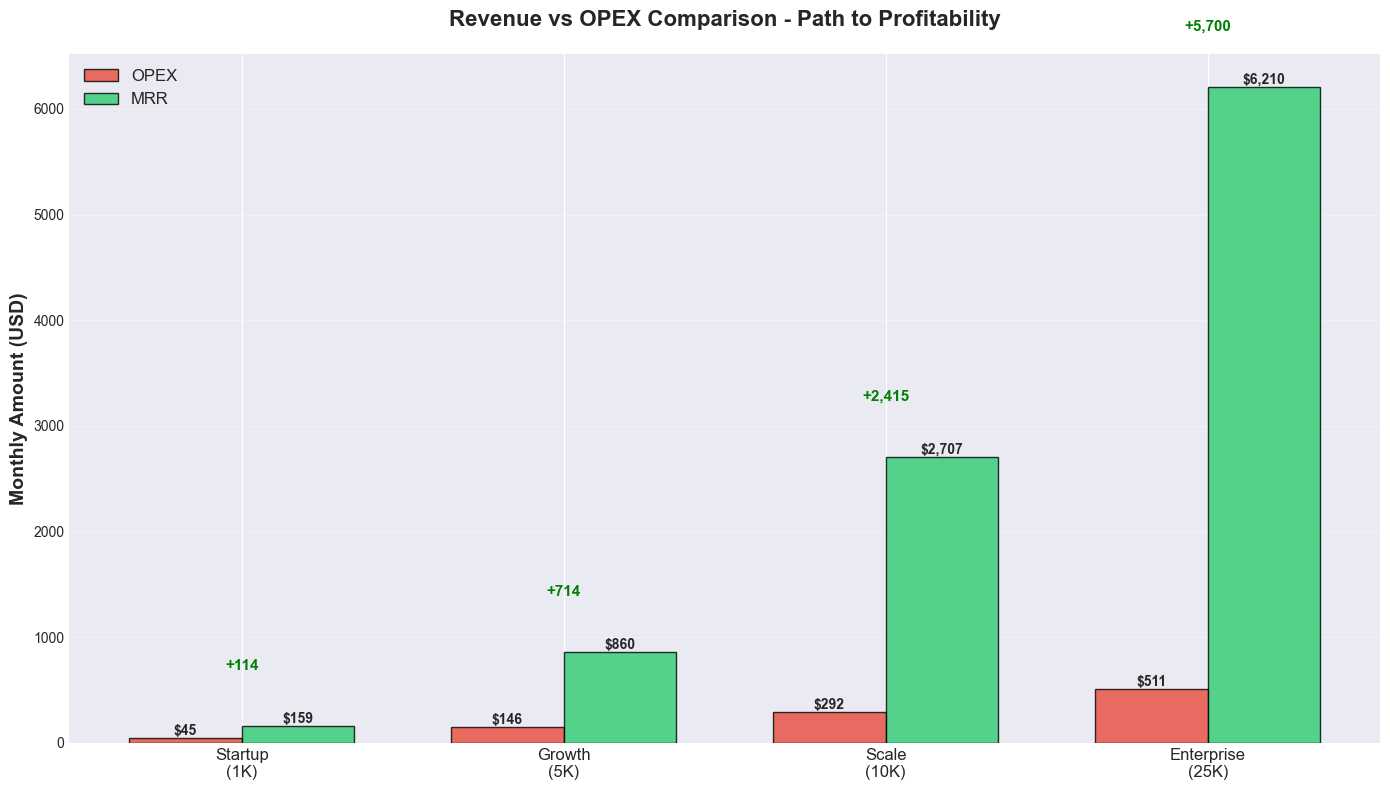

In [ ]:
# Visualize Revenue vs OPEX
fig, ax = plt.subplots(figsize=(14, 8))

scenarios_labels = ['Startup\n(1K)', 'Growth\n(5K)', 'Scale\n(10K)', 'Enterprise\n(25K)']
x = np.arange(len(scenarios_labels))
width = 0.35

bars1 = ax.bar(x - width/2, df_opex['grand_total'], width, label='OPEX', color='#e74c3c', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, df_opex['mrr'], width, label='MRR', color='#2ecc71', alpha=0.8, edgecolor='black')

ax.set_ylabel('Monthly Amount (USD)', fontsize=14, fontweight='bold')
ax.set_title('Revenue vs OPEX Comparison - Path to Profitability', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(scenarios_labels, fontsize=12)
ax.legend(fontsize=12, loc='upper left')
ax.grid(axis='y', alpha=0.3)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:,.0f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
for i, (opex, mrr) in enumerate(zip(df_opex['grand_total'], df_opex['mrr'])):
    profit = mrr - opex
    color = 'green' if profit > 0 else 'red'
    ax.text(i, max(opex, mrr) + 500, f'{"+" if profit > 0 else ""}{profit:,.0f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11, color=color)

plt.tight_layout()
plt.show()


In [44]:
months = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'M10', 'M11', 'M12']
customers_timeline = {
    'starter': [0, 2, 5, 8, 12, 15, 20, 25, 30, 35, 40, 45],
    'professional': [0, 0, 0, 1, 2, 3, 5, 7, 9, 12, 15, 20],
    'enterprise': [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 3]
}

monthly_mrr = []
monthly_opex = []
monthly_profit = []

for i in range(12):
    mrr = ( customers_timeline['starter'][i] * pricing_tiers['starter']['price_per_month'] + customers_timeline['professional'][i] * pricing_tiers['professional']['price_per_month'] + customers_timeline['enterprise'][i] * pricing_tiers['enterprise']['price_per_month'])

    total_customers = (customers_timeline['starter'][i] + customers_timeline['professional'][i] + customers_timeline['enterprise'][i])

    if total_customers <= 5:
        opex = 274
    elif total_customers <= 18:
        opex = 680
    elif total_customers <= 40:
        opex = 1143
    else:
        opex = 1201
    monthly_mrr.append(mrr)
    monthly_opex.append(opex)
    monthly_profit.append(mrr - opex)
df_projection = pd.DataFrame({
'month': months,
    'mrr': monthly_mrr,
    'opex': monthly_opex,
    'profit': monthly_profit,
    'cumulative_profit': np.cumsum(monthly_profit)
})   

print(df_projection.to_string(index=False))
print(f"Year 1 Total Revenue: ${sum(monthly_mrr)}")
print(f"Year 1 Total OPEX: ${sum(monthly_opex)}")
print(f"Year 1 Net Profit: ${sum(monthly_profit)}")
print(f"Break-even Month:      {df_projection[df_projection['cumulative_profit'] > 0].iloc[0]['month'] if any(df_projection['cumulative_profit'] > 0) else 'Not yet'}")
    

month      mrr  opex   profit  cumulative_profit
   M1     0.00   274  -274.00            -274.00
   M2    63.70   274  -210.30            -484.30
   M3   159.25   274  -114.75            -599.05
   M4   382.19   680  -297.81            -896.86
   M5   636.98   680   -43.02            -939.88
   M6   859.92   680   179.92            -759.96
   M7 1,273.95  1143   130.95            -629.01
   M8 1,687.98  1143   544.98             -84.03
   M9 2,579.72  1143 1,436.72           1,352.69
  M10 3,121.14  1201 1,920.14           3,272.83
  M11 4,140.27  1201 2,939.27           6,212.10
  M12 5,414.18  1201 4,213.18          10,425.28
Year 1 Total Revenue: $20319.28
Year 1 Total OPEX: $9894
Year 1 Net Profit: $10425.28
Break-even Month:      M9


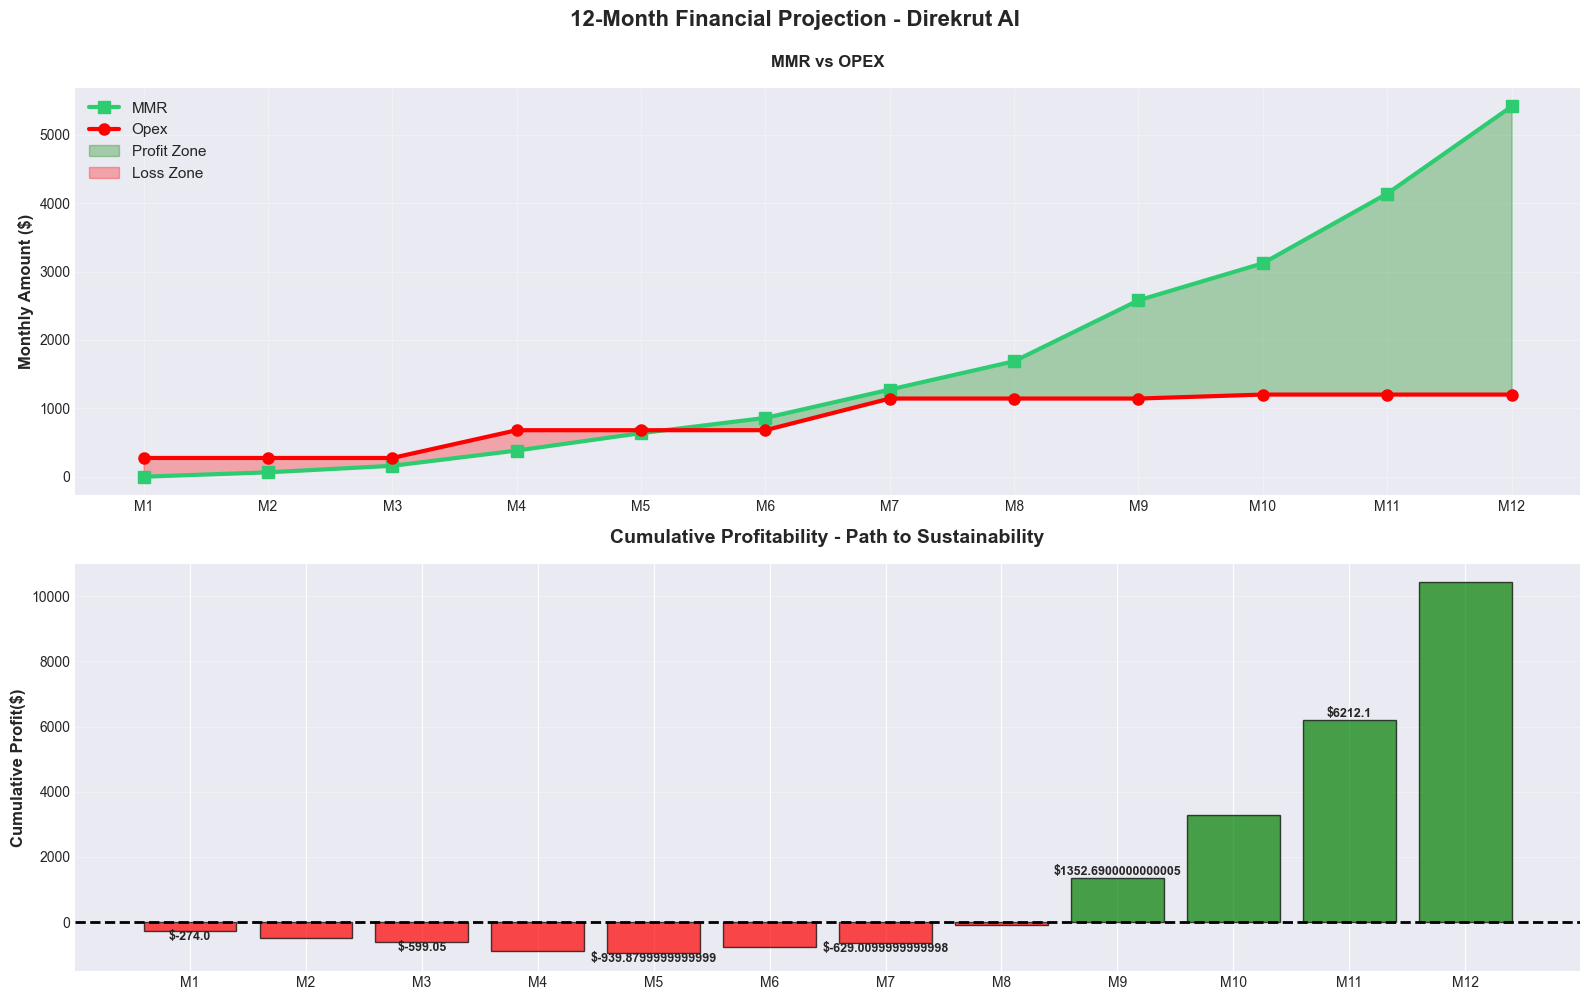

In [65]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('12-Month Financial Projection - Direkrut AI', fontsize=16, fontweight='bold', y=0.995)

ax1 = axes[0]
ax1.plot(df_projection['month'], df_projection['mrr'], marker='s', linewidth=3, label='MMR', color="#2ecc71", markersize=8)
ax1.plot(df_projection['month'], df_projection['opex'], marker='o', linewidth=3, label='Opex', color="red", markersize=8)
ax1.fill_between(df_projection['month'], df_projection['mrr'], df_projection['opex'], where=(df_projection['mrr'] >= df_projection['opex']), interpolate=True, alpha=0.3, color="green", label="Profit Zone")
ax1.fill_between(df_projection['month'], df_projection['mrr'], df_projection['opex'], where=(df_projection['mrr'] < df_projection['opex']), interpolate=True, alpha=0.3, color="red", label="Loss Zone")
ax1.set_ylabel('Monthly Amount ($)', fontsize=12, fontweight='bold')
ax1.set_title('MMR vs OPEX', fontsize=12, fontweight='bold', pad=15 )
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)


ax2 = axes[1]
colors = ['red' if x < 0 else 'green' for x in df_projection['cumulative_profit']]
bars = ax2.bar(df_projection['month'], df_projection['cumulative_profit'], color=colors, alpha=0.7, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax2.set_ylabel('Cumulative Profit($)', fontsize=12, fontweight='bold')
ax2.set_title('Cumulative Profitability - Path to Sustainability', fontsize=14, fontweight='bold', pad=15)
ax2.grid(axis='y', alpha=0.3)

for i, (bar, value) in enumerate(zip(bars, df_projection['cumulative_profit'])):
    if i % 2 == 0:
        ax2.text(bar.get_x() + bar.get_width()/2., value, f'${value}', ha='center', va='bottom' if value > 0 else 'top', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [66]:
breakevenpoint_data = []

for scenario, opex in zip(scenarios, df_opex['grand_total']):
    starter_needed = np.ceil(opex / pricing_tiers['starter']['price_per_month'])
    pro_needed = np.ceil(opex / pricing_tiers['professional']['price_per_month'])
    enterprise_needed = np.ceil(opex / pricing_tiers['enterprise']['price_per_month'])
    breakevenpoint_data.append({
        'scenario': scenario.upper(),
        'monthly_opex': opex,
        'starter_customers': int(starter_needed),
        'professional_customers': int(pro_needed),
        'enterprises_customers': int(enterprise_needed)
    })
df_breakevenpoint = pd.DataFrame(breakevenpoint_data)

print(df_breakevenpoint.to_string(index=False))

  scenario  monthly_opex  starter_customers  professional_customers  enterprises_customers
   STARTUP         45.25                  2                       1                      1
    GROWTH        145.96                  5                       2                      1
     SCALE        291.93                 10                       3                      1
ENTERPRISE        510.82                 17                       5                      2


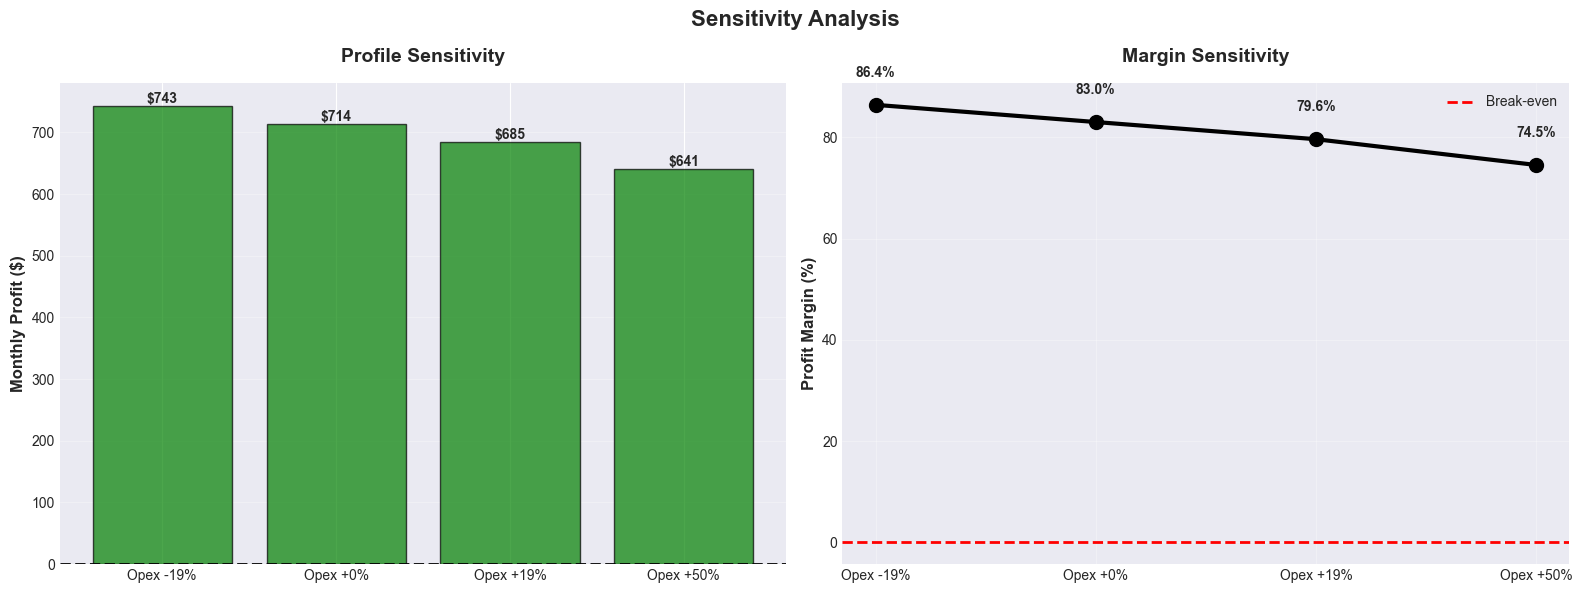

In [70]:
opex_multipliers = [0.8, 1.0, 1.2, 1.5]
sensitivity_results = []

for multiplier in opex_multipliers:
    scenario_name = f'Opex {'-' if multiplier < 1 else '+'}{abs(int((multiplier-1)* 100))}%'
    growth_opex = df_opex.iloc[1]['grand_total'] * multiplier
    growth_mrr = df_opex.iloc[1]['mrr']
    profit = growth_mrr - growth_opex
    margin = (profit / growth_mrr) * 100 if growth_mrr > 0 else 0

    sensitivity_results.append({
        'scenario': scenario_name,
        'opex': growth_mrr,
        'mrr': growth_mrr,
        'profit': profit,
        'margin': margin
    })

df_sensitivity = pd.DataFrame(sensitivity_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Sensitivity Analysis', fontsize=16, fontweight='bold')

ax1= axes[0]
colors = ['green' if x > 0 else 'red' for x in df_sensitivity['profit']]
bars = ax1.bar(df_sensitivity['scenario'], df_sensitivity['profit'], color=colors, alpha=0.7, edgecolor="black")
ax1.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax1.set_ylabel('Monthly Profit ($)', fontsize=12, fontweight='bold')
ax1.set_title('Profile Sensitivity', fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='y', alpha=0.3)

for bar, value in zip(bars, df_sensitivity['profit']):
    ax1.text(bar.get_x() + bar.get_width()/2., value, f'${value:,.0f}', ha='center', va='bottom' if value > 0 else 'top', fontweight='bold', fontsize=10)

ax2 = axes[1]
ax2.plot(df_sensitivity['scenario'], df_sensitivity['margin'], marker='o', linewidth=3, markersize=10, color='#000000')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Break-even')
ax2.set_ylabel('Profit Margin (%)', fontsize=12, fontweight='bold')
ax2.set_title('Margin Sensitivity', fontsize=14, fontweight='bold', pad=15)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

for i, (x, y) in enumerate(zip(df_sensitivity['scenario'], df_sensitivity['margin'])):
    ax2.text(i, y + 5, f'{y:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()
